In [1]:
import torch

In [2]:
import torch.nn as nn

In [3]:
import torch.optim as optim

In [4]:
import torch.nn.functional as F

In [5]:
from torchvision import datasets,transforms

In [6]:
from torch.utils.data import DataLoader

In [8]:
transform=transforms.ToTensor()

In [10]:
train_dataset=datasets.MNIST(root="./data",train=True,download=True,transform=transform)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 15.8MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 7.93MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 1.51MB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



In [12]:
test_dataset=datasets.MNIST(root="./data",train=False,download=True,transform=transform)

In [13]:
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)

In [14]:
test_loader=DataLoader(test_dataset,batch_size=1000,shuffle=False)

In [56]:
class SimpleCNN(nn.Module):
    def __init__(self):
     super(SimpleCNN,self).__init__()
     self.conv1=nn.Conv2d(1,32,kernel_size=3,stride=1,padding=1)
     self.pool1=nn.MaxPool2d(kernel_size=2,stride=2)
     self.conv2=nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1)
     self.pool2=nn.MaxPool2d(kernel_size=2,stride=2)
     self.flatten=nn.Flatten()
     self.fc1=nn.Linear(3136,128)
     self.fc2=nn.Linear(128,10)    
    def forward(self,x):
     x=F.relu(self.conv1(x))  
     x=(self.pool1(x))  
     x=F.relu(self.conv2(x))  
     x=(self.pool2(x))
     x =self.flatten(x)  # Flatten the tensor
     x = self.fc1(x)            # Apply fully connected layer
     x=(self.fc2(x))
     return x    
    

In [57]:
model=SimpleCNN()
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [58]:
def train(model,loader,optimizer,criterion,epochs=2):
 model.train()
 for epoch in range (epochs):
     total_loss=0
     for images,labels in loader:
         outputs=model(images)
         loss=criterion(outputs,labels)
         optimizer.zero_grad()
         loss.backward()
         optimizer.step()
         total_loss+=loss.item()
     print(f"epoch{epoch+1}/{epochs},loss:{total_loss/len(loader):.4f}")
         
     

In [59]:
train(model,train_loader,optimizer,criterion,epochs=2)

epoch1/2,loss:0.1598
epoch2/2,loss:0.0510


In [65]:
def test(model,loader):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for images,labels in loader:
         outputs=model(images)
         j,predicted=torch.max(outputs,1)
         total+=labels.size(0)
         correct+=(predicted==labels).sum().item()
    print(f"test accuracy:{100*correct/total:.2f}%")
    
    

In [66]:
test(model,test_loader)

test accuracy:98.83%


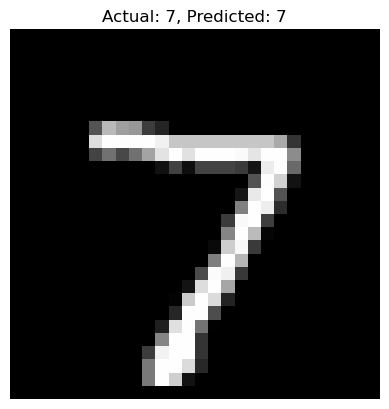

In [68]:
import matplotlib.pyplot as plt

# Get one batch from test_loader
images, labels = next(iter(test_loader))

# Take the first image from that batch
image = images[0].unsqueeze(0)   # add batch dimension (1,1,28,28)
label = labels[0].item()

# Predict
model.eval()
with torch.no_grad():
    output = model(image)
    _, predicted = torch.max(output, 1)

predicted_label = predicted.item()

# Show image + prediction
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Actual: {label}, Predicted: {predicted_label}")
plt.axis("off")
plt.show()


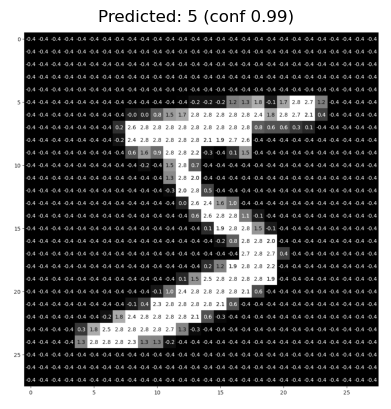

Predicted digit: 5


In [81]:
from PIL import Image
import os

def predict_external(img_path, model, show=True):
 
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"File not found: {img_path}")

 
    img = Image.open(img_path).convert("L")


    transform = transforms.Compose([
        transforms.Resize((28, 28)),          # resize to MNIST size
        transforms.ToTensor(),                # convert to tensor
        transforms.Normalize((0.5,), (0.5,))  # normalize same as training
    ])
    img_tensor = transform(img).unsqueeze(0)  # add batch dimension → (1,1,28,28)


    model.eval()
    with torch.no_grad():
        output = model(img_tensor)               # raw logits
        probs = torch.softmax(output, dim=1)     # convert to probabilities
        predicted = probs.argmax(dim=1).item()
        confidence = probs.max().item()


    if show:
        plt.imshow(img, cmap="gray")
        plt.title(f"Predicted: {predicted} (conf {confidence:.2f})")
        plt.axis("off")
        plt.show()

    return predicted

# -----------------------------
# 🔹 Replace YOUR PATH here!
# -----------------------------
path =  "C:/Users/achyu/Downloads/mnist_digit_pixels.png"  # <-- REPLACE this with your image path

# Run prediction
print("Predicted digit:", predict_external(path, model))